In [1]:
import pandas as pd
df = pd.read_csv("TriNetX_EMER_ICD10.csv")

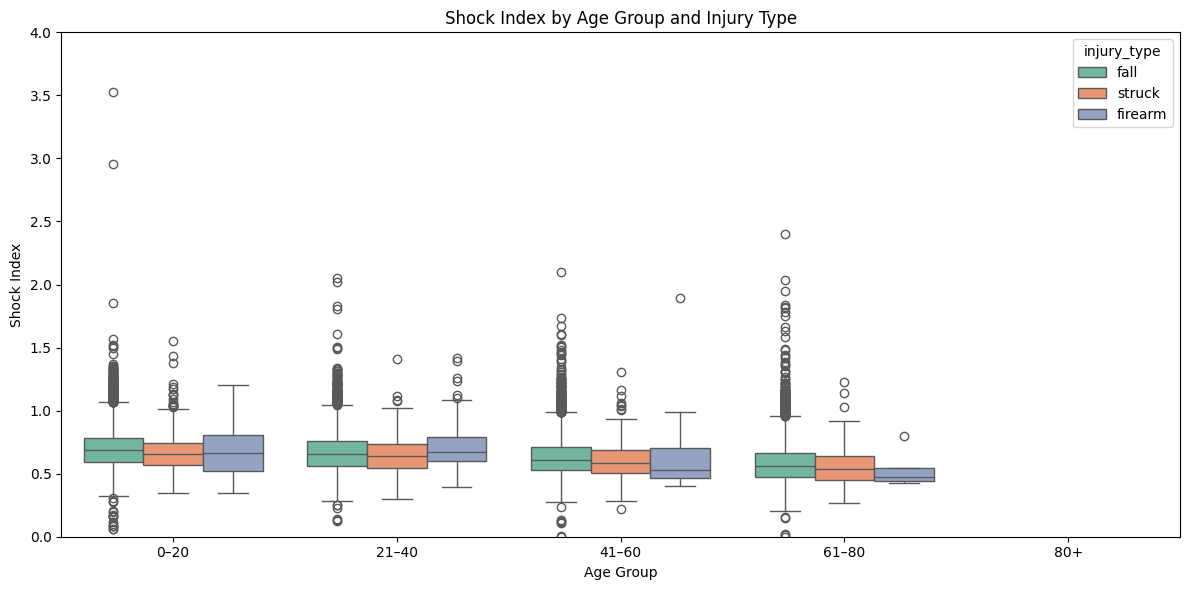

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 0. COLLAPSE ONE-HOT INJURY COLUMNS
# ---------------------------------------------------------
def collapse_onehot(df, cols, new_colname):
    df = df.copy()
    df[new_colname] = df[cols].idxmax(axis=1)
    return df

df_restored = collapse_onehot(df, ["fall", "struck", "firearm"], "injury_type")

# ---------------------------------------------------------
# 1. DEDUPLICATE ENCOUNTERS + FIX DATE
# ---------------------------------------------------------
df_restored = (
    df_restored.sort_values("encounter_id")
               .drop_duplicates("encounter_id", keep="first")
               .copy()
)

df_restored["date"] = pd.to_datetime(df_restored["date"], format="%Y%m%d", errors="coerce")

# ---------------------------------------------------------
# 2. COMPUTE AGE + AGE GROUP
# ---------------------------------------------------------
df_restored["year_of_visit"] = df_restored["date"].dt.year
df_restored["estimated_age"] = df_restored["year_of_visit"] - df_restored["year_of_birth"]

df_restored["age_group"] = pd.cut(
    df_restored["estimated_age"],
    bins=[0, 20, 40, 60, 80, float("inf")],
    labels=["0–20", "21–40", "41–60", "61–80", "80+"],
    right=True
)

# ---------------------------------------------------------
# 3. EXTRACT EARLIEST SBP + HR FROM LOINC CODES
# ---------------------------------------------------------
VS_CODES = ["8480-6", "8867-4"]   # SBP, HR
df_vitals = df[df["code_1"].isin(VS_CODES)].copy()
df_vitals["date"] = pd.to_datetime(df_vitals["date"], format="%Y%m%d", errors="coerce")

# earliest date per encounter
earliest_vs = (
    df_vitals.groupby("encounter_id", as_index=False)["date"]
             .min()
             .rename(columns={"date": "earliest_vs_date"})
)

# keep only vitals from earliest date
df_vs_earliest = df_vitals.merge(earliest_vs, on="encounter_id", how="inner")
df_vs_earliest = df_vs_earliest[df_vs_earliest["date"] == df_vs_earliest["earliest_vs_date"]]

# remove duplicates per code
df_vs_earliest = (
    df_vs_earliest.sort_values(["encounter_id", "code_1", "date"])
                  .drop_duplicates(subset=["encounter_id", "code_1"], keep="first")
)

# pivot to wide
df_vs_wide = (
    df_vs_earliest
    .pivot(index="encounter_id", columns="code_1", values="value")
    .reset_index()
    .rename(columns={"8480-6": "sbp", "8867-4": "hr"})
)

# ---------------------------------------------------------
# 4. MERGE VITALS INTO df_final
# ---------------------------------------------------------
df_final = df_restored.merge(df_vs_wide, on="encounter_id", how="left")

# ---------------------------------------------------------
# 5. COMPUTE SHOCK INDEX + DROP NA
# ---------------------------------------------------------
df_final["shock_index"] = df_final["hr"] / df_final["sbp"]
df_final = df_final.dropna(subset=["shock_index"])

# ---------------------------------------------------------
# 6. BOXPLOT
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_final,
    x="age_group",
    y="shock_index",
    hue="injury_type",
    palette="Set2"
)

plt.title("Shock Index by Age Group and Injury Type")
plt.xlabel("Age Group")
plt.ylabel("Shock Index")
plt.ylim(0, 4)
plt.tight_layout()
plt.show()



In [3]:
df_final

,patient_id,encounter_id,code_system,code,patient_id_1,sex,race,ethnicity,marital_status,year_of_birth,...,fall,firearm,struck,injury_type,year_of_visit,estimated_age,age_group,sbp,hr,shock_index
0,8AJd,#A10WB,ICD-10-CM,W19.XXXA,8AJd,M,Unknown,Unknown,Unknown,1957,...,1,0,0,fall,2023,66,61–80,160.0,90.0,0.562500
3,8gnR,#A1ly,ICD-10-CM,W01.0XXA,8gnR,F,Unknown,Unknown,Unknown,1990,...,1,0,0,fall,2021,31,21–40,94.0,121.0,1.287234
4,8gOc,#A1qTB,ICD-10-CM,X58.XXXA,8gOc,M,Unknown,Unknown,Unknown,1961,...,0,0,0,fall,2021,60,41–60,130.0,77.0,0.592308
7,8gUN,#A2Gl,ICD-10-CM,X39.8XXA,8gUN,M,Unknown,Unknown,Unknown,1949,...,0,0,0,fall,2021,72,61–80,174.0,119.0,0.683908
8,8wpV,#A2l#,ICD-10-CM,Y33.XXXA,8wpV,M,Unknown,Unknown,Unknown,1963,...,0,0,0,fall,2022,59,41–60,177.0,92.0,0.519774
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174066,vwPKF,ywvFC,ICD-10-CM,W01.198A,vwPKF,F,White,Not Hispanic or Latino,Single,1961,...,1,0,0,fall,2017,56,41–60,143.0,48.0,0.335664
174081,vQ#LF,yww_M,ICD-10-CM,Y99.9,vQ#LF,M,White,Not Hispanic or Latino,Single,1960,...,0,0,0,fall,2020,60,41–60,97.0,68.0,0.701031
174100,vQOPF,ywz6U,ICD-10-CM,W01.198A,vQOPF,F,Unknown,Hispanic or Latino,Single,1958,...,1,0,0,fall,2025,67,61–80,208.0,82.0,0.394231
174111,vwkSF,ywzxe,ICD-10-CM,W01.198A,vwkSF,M,Unknown,Unknown,Single,1980,...,1,0,0,fall,2021,41,41–60,152.0,103.0,0.677632


In [4]:
df_final.to_csv("df_final_shock_index.csv", index=False)